dataset_name = Student performance dataset
kaggle_link = https://www.kaggle.com/datasets/devansodariya/student-performance-data

# Part1

In [ ]:
import pandas as pd

df = pd.read_csv('C:/Users/kumar/OneDrive/Desktop/TRY-2/Tasks-Submission/Assignment15/student_data.csv')

# Print shape
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# First 5 rows
df.head()

Shape: (395, 33)

Columns:
 Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Task1

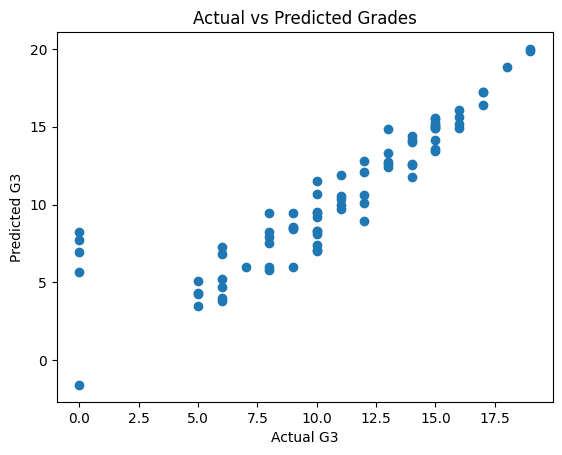

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    classification_report,
    confusion_matrix
)

X = df[['studytime', 'absences', 'G1', 'G2']]
y = df['G3']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Grades")
plt.show()



# Part2

# Task2

In [5]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)


MAE : 1.3125749396243553
MSE : 4.178975406386836
RMSE: 2.0442542421105148


# Part3

# Task3

In [8]:
df['pass'] = (df['G3'] >= 10).astype(int)

X = df[['studytime', 'absences', 'G1', 'G2']]
y = df['pass']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)


# Task4

In [7]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)


# Task5

In [9]:
k_values = [3, 5, 7]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    knn_results[k] = acc
    print(f"K={k}, Accuracy={acc}")
best_k = max(knn_results, key=knn_results.get)
print("Best K:", best_k)


K=3, Accuracy=0.9240506329113924
K=5, Accuracy=0.9113924050632911
K=7, Accuracy=0.9113924050632911
Best K: 3


# Part4

# Task6

In [10]:
print("Logistic Regression Report")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.81      0.93      0.86        27
           1       0.96      0.88      0.92        52

    accuracy                           0.90        79
   macro avg       0.88      0.91      0.89        79
weighted avg       0.91      0.90      0.90        79

[[25  2]
 [ 6 46]]


In [11]:
print("Naive Bayes Report")
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))


Naive Bayes Report
              precision    recall  f1-score   support

           0       0.77      0.89      0.83        27
           1       0.94      0.87      0.90        52

    accuracy                           0.87        79
   macro avg       0.86      0.88      0.86        79
weighted avg       0.88      0.87      0.88        79

[[24  3]
 [ 7 45]]


In [12]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Report")
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))


KNN Report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        27
           1       0.94      0.94      0.94        52

    accuracy                           0.92        79
   macro avg       0.92      0.92      0.92        79
weighted avg       0.92      0.92      0.92        79

[[24  3]
 [ 3 49]]


# Part5

# Task7

In [13]:
knn_simple = KNeighborsClassifier(n_neighbors=1)
knn_simple.fit(X_train, y_train)

print("Train Accuracy (Underfit):", knn_simple.score(X_train, y_train))
print("Test Accuracy (Underfit):", knn_simple.score(X_test, y_test))


Train Accuracy (Underfit): 0.9778481012658228
Test Accuracy (Underfit): 0.8860759493670886


In [14]:
knn_complex = KNeighborsClassifier(n_neighbors=len(X_train))
knn_complex.fit(X_train, y_train)

print("Train Accuracy (Overfit):", knn_complex.score(X_train, y_train))
print("Test Accuracy (Overfit):", knn_complex.score(X_test, y_test))


Train Accuracy (Overfit): 0.6740506329113924
Test Accuracy (Overfit): 0.6582278481012658


# Task8

1️ Bias

Error due to overly simple assumptions in the model.

2️ Variance

Error due to sensitivity to training data fluctuations.

3️ Relation to fitting

High bias → Underfitting

High variance → Overfitting

4 Reduce overfitting

More training data

Feature selection

Regularization

Cross-validation

Simpler models